## BETO for Text Classification

Packages Installation

In [1]:
!pip install pysentimiento transformers datasets accelerate evaluate
!pip install ipdb
!pip install unidecode

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

Let's load a dataset -- in this case, a Spanish sentiment analysis dataset from CardiffNLP.

## Imports


In [2]:
import torch
from datasets import load_dataset
import unicodedata
import pandas as pd

import numpy as np
import evaluate
from pysentimiento.preprocessing import preprocess_tweet

from transformers import AutoModelForSequenceClassification, AutoTokenizer

from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix

import unicodedata

## Helper Functions

In [3]:
#keep slangs with only one word and less than 3 characters
def exclude_slangs(text):
    return len(text.split()) > 1 or len(text) <= 3

def apply_slang_exclusion(df_slangs):
    df_slangs = df_slangs[df_slangs.type.isin(["Jerga","expresión"])]
    df_slangs['slang'] = df_slangs['slang'].apply(lambda x: x.lower())
    df_slangs['exclude_slang'] = df_slangs['slang'].apply(lambda x: exclude_slangs(x))
    dfs = df_slangs[df_slangs.exclude_slang.isin([False])]
    return dfs

In [4]:
def remove_accents(text):
    return ''.join((c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn'))

## Load Dataset

In [5]:
ds = load_dataset("pyupeu/social-media-peruvian-sentiment",revision='4e797116f481d2a545e52cccbc29017fbf994fcc')
ds

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/7574 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2367 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1894 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count'],
        num_rows: 7574
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count'],
        num_rows: 2367
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count'],
        num_rows: 1894
    })
})

## Load Slangs Dictionary
We are going to add new tokens from our Peruvian Slang dataset that are unknown to the model (around 1800 words), and then we will resize the model embeddings.

In [6]:
ds_slangs = load_dataset("pyupeu/peruvian-slangs-dictionary")
ds_slangs

Generating train split:   0%|          | 0/2344 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'slang', 'type', 'short_description', 'description', 'source'],
        num_rows: 2344
    })
})

In [7]:
df_slangs = ds_slangs['train'].to_pandas()

## Helper Funtions

In [8]:
ds["train"].features

{'text': Value(dtype='string', id=None),
 'label': Value(dtype='int64', id=None),
 'label_name': Value(dtype='string', id=None),
 'text_original': Value(dtype='string', id=None),
 'tokenized_text': Value(dtype='string', id=None),
 'sent_token_length': Value(dtype='int64', id=None),
 'sent_bert_token_length': Value(dtype='int64', id=None),
 'char_count': Value(dtype='int64', id=None),
 'Character Count': Value(dtype='int64', id=None)}

In [9]:
ds["test"]["text"][:10]

['christian a. palomino christofher k. chqu carlos novoa chavez fiorella vilchez katherine ardiles podríamos hacer estooo ? 😭😭😭 salgamos parfavar...!',
 'la chuecona no pasa nada es gorda no tiene forma mil veces xoana un amor 😋',
 'para pulirla necesita una lija de fierro la más gruesa, o talves se canso de pulir 🤦🏻\u200d️🤦🏻\u200d️🤦🏻\u200d️🤣🤣🤣👍👍👍',
 '🤮🤮🤮 guacala ese maletero',
 'xabier cañola miñan que hago yo ahí? 😂😂😂',
 'recontra flaca. obvio métele al panetón pero también un par de papás al caldo  😂😂😂',
 'victor quiroz el cuto quiroz ,tu tbm tienes tu cachito pura vida 😂😂😂',
 'daniel daniela micaela vao! 😉',
 'wao eres un capo! como le haces para meter tanta comida jaja 😄😃😃😅 muy buen vídeo !! resalta lo mejor de la selva',
 'que rico, en argentina es un plato de cuando yo era chica y cuando yo alimentaba a mi familia. con el tiempo se ha perdido un poco pero para mi es un clásico. solo algunas variantes el pollo en 8 presas, morron colorado en lugar del ají amarillo que acá no tene

In [10]:
ds["test"]["label"][:10]

[1, 0, 2, 0, 1, 1, 1, 1, 2, 1]

In [11]:
df_slangs = ds_slangs['train'].to_pandas()
dfs = apply_slang_exclusion(df_slangs)
slangs = dfs['slang'].values.tolist()
len(slangs)

1894

## Model and Tokenizer

In [12]:
model_name = "dccuchile/bert-base-spanish-wwm-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.model_max_length = 128

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.cuda()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## Preprocessing

Before tokenizing our model, we have to run the `preprocess_tweet` function to our data.


In [14]:
# preprocessed_ds = ds.map(lambda ex: {"text": preprocess_tweet(ex["text"], lang="es", demoji=False)})

preprocessed_ds = ds.map(lambda ex: {
    "text": remove_accents(preprocess_tweet(ex["text"], lang="es", demoji=False).lower())
})

Map:   0%|          | 0/7574 [00:00<?, ? examples/s]

Map:   0%|          | 0/2367 [00:00<?, ? examples/s]

Map:   0%|          | 0/1894 [00:00<?, ? examples/s]

In [15]:
preprocessed_ds["train"]["text"][:10]

['renzo crispin javier guere baluarte se pasaron de burros 🤣',
 'chino risas pa que llevas a tus maleteros 🤡🤡🤡',
 'estudia p chato 😵\u200d💫🙈',
 'no seas pendejo, jaja tatuaje borra entonces... 😂',
 'todas las autoridades y las actuales son culpables que kuelap se encuentre en esta situacion. son una tira de incapaces 😡',
 'lo que me preocupa es que el perrito esta tranquilo y feliz...espero no haya estado en una casa donde lo maltrataban... ojala termine en buenas manos!! natalia te vas al cielo sin escalas! 🙏🏻🙏🏻',
 '🔵🔴los productos de primera necesidades no pueden ser regulados gracias a la constitucion fujimorista del 93 articulo 62, 63  la constitucion prohibe la regulacion de precios, los productores pueden subirlos sin dar explicaciones a nadie. estas son las principales:  grupo romero -aportante de fuerza popular. duenos de alicorp,  produce fideos nicolini, don vittorio, alianza, lavaggi, aceite primor, cocinero, cil, friol, aceite tri a, capri, alacena; detergente sapolio, boli

## Tokenization

In [16]:
tokenized_ds = preprocessed_ds.map(
    lambda batch: tokenizer(batch["text"], padding=False, truncation=True),
    batched=True, batch_size=32
)

Map:   0%|          | 0/7574 [00:00<?, ? examples/s]

Map:   0%|          | 0/2367 [00:00<?, ? examples/s]

Map:   0%|          | 0/1894 [00:00<?, ? examples/s]

In [17]:
tokenized_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7574
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2367
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1894
    })
})

## Training

In [18]:
f1_metric = evaluate.load("f1")
recall_metric = evaluate.load("recall")

def compute_metrics (eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis = -1)

    results = {}
    results.update(f1_metric.compute(predictions=preds, references = labels, average="macro"))
    results.update(recall_metric.compute(predictions=preds, references = labels, average="macro"))
    return results

In [19]:
tokenizer.add_tokens(slangs)

1887

In [20]:
model.resize_token_embeddings(len(tokenizer))#https://huggingface.co/docs/transformers/main_classes/tokenizer

Embedding(32609, 768)

In [21]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

training_args = TrainingArguments(
    per_device_train_batch_size=32,
    warmup_ratio=0.1,
    learning_rate=5e-5,
    output_dir="test_trainer",
    do_eval=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=5,
    load_best_model_at_end=True,
    seed=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)
trainer.train()

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


{'eval_loss': 0.6813355088233948, 'eval_f1': 0.6707532881688173, 'eval_recall': 0.6657647867405133, 'eval_runtime': 11.9494, 'eval_samples_per_second': 198.084, 'eval_steps_per_second': 24.771, 'epoch': 1.0}
{'eval_loss': 0.6815937757492065, 'eval_f1': 0.6740279950873621, 'eval_recall': 0.6714111910697208, 'eval_runtime': 11.9652, 'eval_samples_per_second': 197.823, 'eval_steps_per_second': 24.738, 'epoch': 2.0}
{'loss': 0.652, 'grad_norm': 4.347571849822998, 'learning_rate': 3.212945590994372e-05, 'epoch': 2.109704641350211}
{'eval_loss': 0.8819544315338135, 'eval_f1': 0.6766018675985682, 'eval_recall': 0.6771249934229714, 'eval_runtime': 11.9908, 'eval_samples_per_second': 197.401, 'eval_steps_per_second': 24.686, 'epoch': 3.0}
{'eval_loss': 1.2269090414047241, 'eval_f1': 0.6881105970875527, 'eval_recall': 0.6939806262283449, 'eval_runtime': 12.0086, 'eval_samples_per_second': 197.109, 'eval_steps_per_second': 24.649, 'epoch': 4.0}
{'loss': 0.177, 'grad_norm': 0.19039097428321838, 'l

TrainOutput(global_step=1185, training_loss=0.3567878393181266, metrics={'train_runtime': 787.0006, 'train_samples_per_second': 48.119, 'train_steps_per_second': 1.506, 'train_loss': 0.3567878393181266, 'epoch': 5.0})

In [22]:
evaluation_results = trainer.evaluate(tokenized_ds["test"])

{'eval_loss': 0.6785308122634888, 'eval_f1': 0.6651380292336958, 'eval_recall': 0.6617158570214327, 'eval_runtime': 9.7975, 'eval_samples_per_second': 193.315, 'eval_steps_per_second': 24.19, 'epoch': 5.0}


In [23]:
predictions = trainer.predict(tokenized_ds["test"])
predictions

PredictionOutput(predictions=array([[-0.9849593 ,  1.0927969 ,  0.37402996],
       [ 2.130295  , -1.8118073 , -1.2271899 ],
       [ 1.0638443 ,  0.4970699 , -1.8907753 ],
       ...,
       [-0.03378563, -0.605788  ,  0.54397297],
       [ 2.461802  , -2.1664948 , -1.5207279 ],
       [-0.98449236,  1.1607293 ,  0.22881126]], dtype=float32), label_ids=array([1, 0, 2, ..., 2, 0, 1]), metrics={'test_loss': 0.6785308122634888, 'test_f1': 0.6651380292336958, 'test_recall': 0.6617158570214327, 'test_runtime': 9.9784, 'test_samples_per_second': 189.809, 'test_steps_per_second': 23.751})

In [24]:
true_labels = tokenized_ds["test"]['label']

In [25]:
from sklearn.metrics import classification_report
predicted_labels = [np.argmax(pred) for pred in predictions[0]]
classification_rep = classification_report(true_labels, predicted_labels, digits=5)

print(classification_rep)

              precision    recall  f1-score   support

           0    0.77691   0.86587   0.81898       917
           1    0.44743   0.52632   0.48368       380
           2    0.83294   0.59296   0.69276       597

    accuracy                        0.71172      1894
   macro avg    0.68576   0.66172   0.66514      1894
weighted avg    0.72847   0.71172   0.71192      1894



In [26]:
# Error Analisys
## Test on Validation set

In [27]:
val_df = ds['validation'].to_pandas()
# We do this to view predictions in the pandas dataframe and easily filter them and perform error analysis.
pred_final = []

for i, row in tqdm(val_df.iterrows(), total=val_df.shape[0]):
    predictions = []

    text = row["text"]
    encoded_data_test_single = tokenizer.batch_encode_plus([text],
    # add_special_tokens=config.add_special_tokens,
    # return_attention_mask=config.return_attention_mask,
    # pad_to_max_length=config.pad_to_max_length,
    max_length=128,
    # return_tensors=config.return_tensors
    return_tensors="pt"
    )
    input_ids_test = encoded_data_test_single['input_ids']
    attention_masks_test = encoded_data_test_single['attention_mask']


    inputs = {'input_ids':      input_ids_test.to(device),
              'attention_mask':attention_masks_test.to(device),
             }

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs[0]
    logits = logits.detach().cpu().numpy()
    predictions.append(logits)
    predictions = np.concatenate(predictions, axis=0)
    pred_final.append(np.argmax(predictions, axis=1).flatten()[0])

  0%|          | 0/2367 [00:00<?, ?it/s]

In [30]:
# add pred into val_df
val_df["pred"] = pred_final

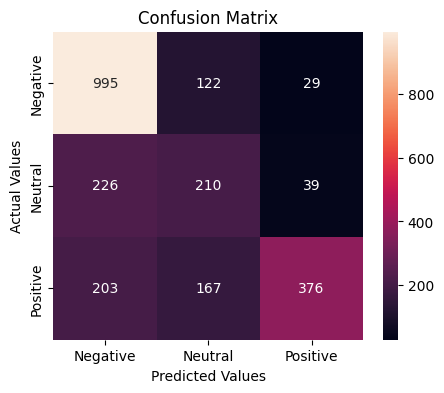

In [32]:
#  Add control column for easier wrong and right predictions
control = val_df.pred.values == val_df.label.values
val_df["control"] = control

# label to intent mapping
name2label = {"Negative":0,
              "Neutral":1,
             "Positive":2
             }
label2name = {v: k for k, v in name2label.items()}

val_df["pred_name"] = val_df.pred.apply(lambda x: label2name.get(x))


# We create a confusion matrix to better observe the classes that the model confuses.
pred_name_values = val_df.pred_name.values
label_values = val_df.label_name.values
confmat = confusion_matrix(label_values, pred_name_values, labels=list(name2label.keys()))

df_confusion_val = pd.crosstab(label_values, pred_name_values)

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(label_values, pred_name_values)
cm_df = pd.DataFrame(cm,
                     index = ['Negative','Neutral','Positive'],
                     columns = ['Negative','Neutral','Positive'])
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True,fmt=".0f")
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

In [34]:
cm

array([[995, 122,  29],
       [226, 210,  39],
       [203, 167, 376]])

In [35]:
## Test Inference

In [36]:
test_df = ds['test'].to_pandas()

In [37]:
# We do this to view predictions in the pandas dataframe and easily filter them and perform error analysis.
pred_test_final = []

for i, row in tqdm(test_df.iterrows(), total=test_df.shape[0]):
    predictions = []

    text = row["text"]
    encoded_data_test_single = tokenizer.batch_encode_plus([text],
    # add_special_tokens=config.add_special_tokens,
    # return_attention_mask=config.return_attention_mask,
    # pad_to_max_length=config.pad_to_max_length,
    max_length=128,
    # return_tensors=config.return_tensors
    return_tensors="pt"
    )
    input_ids_test = encoded_data_test_single['input_ids']
    attention_masks_test = encoded_data_test_single['attention_mask']


    inputs = {'input_ids':      input_ids_test.to(device),
              'attention_mask':attention_masks_test.to(device),
             }

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs[0]
    logits = logits.detach().cpu().numpy()
    predictions.append(logits)
    predictions = np.concatenate(predictions, axis=0)
    pred_test_final.append(np.argmax(predictions, axis=1).flatten()[0])

  0%|          | 0/1894 [00:00<?, ?it/s]

In [38]:
# add pred into val_df
test_df["pred"] = pred_test_final

In [44]:
# label to intent mapping
name2label = {"Negative":0,
              "Neutral":1,
             "Positive":2
             }
label2name = {v: k for k, v in name2label.items()}

test_df["pred_name"] = test_df.pred.apply(lambda x: label2name.get(x))

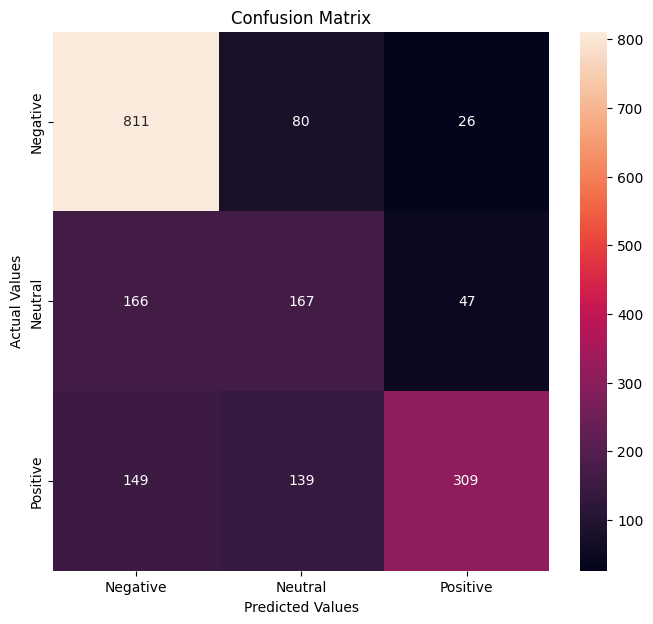

<Figure size 640x480 with 0 Axes>

In [53]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred_name_values = test_df.pred_name.values
label_values = test_df.label_name.values
cm = confusion_matrix(label_values, pred_name_values)
cm_df = pd.DataFrame(cm,
                     index = ['Negative','Neutral','Positive'],
                     columns = ['Negative','Neutral','Positive'])
plt.figure(figsize=(8,7))
sns.heatmap(cm_df, annot=True,fmt=".0f")
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

plt.savefig('cm_test_predictions.png')

In [54]:
# save confusion matrix df
cm_df.to_csv("BETO_val_df_confusion.csv")

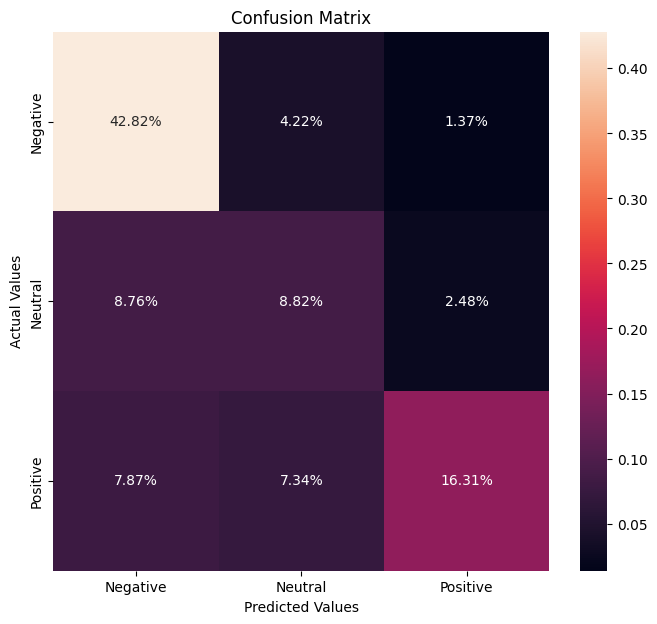

In [46]:
#Test inference in percentages
cm = confusion_matrix(label_values, pred_name_values)
cm_df = pd.DataFrame(cm/np.sum(cm),
                     index = ['Negative','Neutral','Positive'],
                     columns = ['Negative','Neutral','Positive'])
plt.figure(figsize=(8,7))
sns.heatmap(cm_df, annot=True, fmt=".2%")
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.savefig('cm_test_predictions_percentage.png')
plt.show()

In [48]:
cm_df

,Negative,Neutral,Positive
Negative,0.428194,0.042239,0.013728
Neutral,0.087645,0.088173,0.024815
Positive,0.078669,0.073390,0.163147


In [51]:
# save confusion matrix df
cm_df.to_csv("BETO_val_df_confusion_percentages.csv")